
# 03 &nbsp;|&nbsp; Static Baseline Model

**Dissertation:** *Temporal Prediction of In-Trial Adverse Events in Oncology Clinical Trials Using Machine Learning*

---

## Purpose

This notebook implements **Phase 5 (Initial Baseline Modeling and Validation)**: the
patient-level static model that the mid-semester report defines as the methodological
benchmark against which the temporal design must be judged.

**Problem statement.** One row per patient. Using only information available at or before
the first dose of study treatment, predict whether the patient will experience any
treatment-emergent CTCAE Grade ≥3 adverse event within the following 30 days.

| Design element | Choice |
|---|---|
| Unit of prediction | Patient |
| Feature cut-off | First dose of study treatment (study day 1) |
| Target | Any Grade ≥3 treatment-emergent AE in days 1–31 |
| Validation | 5-fold stratified cross-validation + held-out patient test set |
| Reference model | L2-penalised logistic regression |

The deliberate limitation of this design — that it can only speak about the first 30 days
and never updates — is exactly what notebook 05 sets out to overcome.

In [ ]:
# --- environment setup -------------------------------------------------------
import sys, warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from aeprep import io, quality, labels, features_static, features_temporal
from aeprep import modeling, evaluation, plots
from aeprep.config import CFG, DATASET_DIR, FIGURE_DIR, TABLE_DIR, MODEL_DIR, ensure_output_dirs

ensure_output_dirs()
plots.set_style()
pd.set_option("display.width", 190)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

print(f"project root : {PROJECT_ROOT}")
print(f"pandas {pd.__version__} | numpy {np.__version__}")
print(f"analysis config: horizon={CFG.prediction_horizon_days}d, "
      f"grade>={CFG.severity_threshold}, landmark step={CFG.landmark_step_days}d")

project root : C:\BITS M Tech\Sem 4 Dissertation\Sem 4 Dissertation\ProjectWork\project-root
pandas 2.3.3 | numpy 2.3.5
analysis config: horizon=30d, grade>=3, landmark step=14d


In [ ]:
domains = io.load_all_domains()
timeline = pd.read_parquet(DATASET_DIR / "patient_timeline.parquet")
ae = io.tidy_adverse(domains["adverse"])


## 1. Building the patient-level analytic dataset

### 1.1 Target

In [ ]:
static_target = labels.static_label(ae, timeline)

print(f"Patients                       : {len(static_target)}")
print(f"Window                         : day {static_target['window_start'].iloc[0]:.0f} "
      f"to day {static_target['window_end'].iloc[0]:.0f}")
print(f"Fully observed 30-day window   : {int(static_target['window_complete'].sum())}")
print(f"Informative (event or complete): {int(static_target['informative'].sum())}")
print(f"Positive class                 : {int(static_target['y'].sum())} "
      f"({static_target['y'].mean():.1%})")

static_target.head()

Patients                       : 379
Window                         : day 1 to day 31
Fully observed 30-day window   : 372
Informative (event or complete): 378
Positive class                 : 87 (23.0%)


,PID,window_start,window_end,y,n_severe_in_window,first_severe_day,max_grade_in_window,window_complete,informative
0,0001,1.0000,31.0000,1,1,28.0000,3.0000,True,True
1,0002,1.0000,31.0000,1,1,21.0000,4.0000,True,True
2,0003,1.0000,31.0000,0,0,NaN,NaN,True,True
3,0004,1.0000,31.0000,0,0,NaN,NaN,True,True
4,0005,1.0000,31.0000,1,2,5.0000,4.0000,True,True


In [ ]:
excluded = static_target[~static_target["informative"]]
print(f"{len(excluded)} patient(s) excluded — the 30-day window was censored before any "
      f"severe event could be observed:")
excluded.merge(timeline[["PID", "ae_obs_end", "eot_day", "discont_reason"]],
               on="PID", how="left")

1 patient(s) excluded — the 30-day window was censored before any severe event could be observed:


,PID,window_start,window_end,y,n_severe_in_window,first_severe_day,max_grade_in_window,window_complete,informative,ae_obs_end,eot_day,discont_reason
0,0362,1.0000,31.0000,0,0,NaN,NaN,False,False,5.0000,5.0000,SUBJECT REFUSED CONTINUED TREATMENT FOR REASON...



### 1.2 Features

All 92 baseline features come from `aeprep.features_static`. Every block is derived from
records dated at or before the first dose, so nothing in the matrix would have been
unavailable to a clinician on the day treatment started.

In [ ]:
baseline = features_static.build_baseline_features(domains, timeline)

blocks = {
    "Demographics / anthropometry": ["age", "age_ge_65", "sex_male", "race",
                                     "height_cm", "weight_kg", "bmi", "bsa_m2"],
    "Performance status": [c for c in baseline.columns if c.startswith("ecog")],
    "Baseline vital signs": [c for c in baseline.columns if c.startswith("bl_")
                             and not c.startswith(("bl_conmed", "bl_lab"))],
    "Medical history": [c for c in baseline.columns if c.startswith("mh_")
                        or c in ("n_medical_history", "n_ongoing_conditions")],
    "Disease history": ["months_since_diagnosis", "newly_diagnosed_lt6m"],
    "Baseline concomitant medication": [c for c in baseline.columns
                                        if c.startswith("bl_conmed") or c == "n_baseline_conmeds"],
    "Starting dose / exposure": [c for c in baseline.columns if c.startswith("start_dose")],
    "Physical examination": [c for c in baseline.columns if c.startswith("n_") and "system" in c],
    "Pre-treatment toxicity": [c for c in baseline.columns if "pretreatment" in c],
    "Baseline laboratory panel": [c for c in baseline.columns if c.startswith("bl_lab")],
}
pd.DataFrame([{"feature block": k, "n_features": len(v), "features": ", ".join(v)[:95]}
              for k, v in blocks.items()])

,feature block,n_features,features
0,Demographics / anthropometry,8,"age, age_ge_65, sex_male, race, height_cm, wei..."
1,Performance status,2,"ecog_baseline, ecog_baseline_ge1"
2,Baseline vital signs,24,"bl_sbp, bl_dbp, bl_hr, bl_rr, bl_temp, bl_weig..."
3,Medical history,12,"n_medical_history, n_ongoing_conditions, mh_ca..."
4,Disease history,2,"months_since_diagnosis, newly_diagnosed_lt6m"
5,Baseline concomitant medication,7,"n_baseline_conmeds, bl_conmed_growth_factor, b..."
6,Starting dose / exposure,7,"start_dose_blinded, start_dose_fluorouracil, s..."
7,Physical examination,2,"n_systems_examined, n_abnormal_systems"
8,Pre-treatment toxicity,2,"n_pretreatment_ae, max_pretreatment_grade"
9,Baseline laboratory panel,28,"bl_lab_hgb, bl_lab_wbc, bl_lab_anc, bl_lab_plt..."


48 of 94 baseline features have missing values


,n_missing,pct_missing
bl_days_since_radiotherapy,331,87.3400
bl_days_since_prior_therapy,304,80.2100
bl_prior_stopped_for_progression,292,77.0400
bl_prior_stopped_for_toxicity,292,77.0400
bl_prior_neoadjuvant,285,75.2000
bl_prior_adjuvant,285,75.2000
bl_n_prior_regimens,141,37.2000
bl_lab_eos,133,35.0900
bl_lab_lym,127,33.5100
bl_lab_mono,127,33.5100


findfont: Failed to find font weight semibold, now using 700.


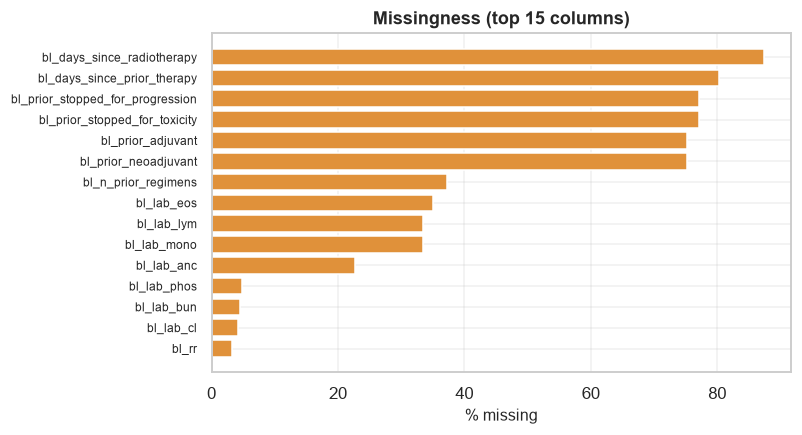

In [ ]:
missing = quality.missingness_report(baseline)
print(f"{len(missing)} of {baseline.shape[1]} baseline features have missing values")
display(missing.head(15))

fig, ax = plt.subplots(figsize=(6.8, 4.0))
plots.plot_missingness(baseline, top_n=15, ax=ax)
plots.save(fig, "03_baseline_missingness")
plt.show()


Missingness is low and concentrated in vital signs that a site simply did not record at
the screening visit. It is handled inside the model pipeline by median imputation with a
missing-indicator, so "not measured" can itself carry signal.

In [ ]:
analytic = (baseline.join(static_target.set_index("PID")[["y", "informative"]])
                    .query("informative")
                    .drop(columns=["informative"]))

y = analytic.pop("y")
X = analytic
groups = pd.Series(X.index, index=X.index, name="PID")

print(f"Design matrix: {X.shape[0]} patients x {X.shape[1]} features")
print(f"Positive class: {int(y.sum())} ({y.mean():.1%})")

X_clean, dropped = modeling.drop_uninformative_columns(X, verbose=True)
display(dropped)
X = X_clean

analytic_out = X.copy(); analytic_out["y"] = y
analytic_out.to_parquet(DATASET_DIR / "static_analytic_dataset.parquet")
print(f"saved -> {DATASET_DIR / 'static_analytic_dataset.parquet'}")

Design matrix: 378 patients x 94 features
Positive class: 87 (23.0%)
  dropped 2 uninformative columns


,column,reason,value
0,bl_conmed_growth_factor,constant,0.0000
1,start_dose_blinded,constant,0.0000


saved -> C:\BITS M Tech\Sem 4 Dissertation\Sem 4 Dissertation\ProjectWork\project-root\outputs\datasets\static_analytic_dataset.parquet



## 2. Univariable screening

Before fitting anything, a simple association screen shows how much baseline signal exists
at all. This sets expectations: if no single baseline variable separates the classes, a
multivariable model is unlikely to achieve strong discrimination.

In [ ]:
from scipy import stats

rows = []
for c in X.select_dtypes("number").columns:
    a, b = X.loc[y == 1, c].dropna(), X.loc[y == 0, c].dropna()
    if len(a) < 5 or len(b) < 5:
        continue
    u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    auc = u / (len(a) * len(b))
    rows.append({"feature": c, "mean_event": a.mean(), "mean_no_event": b.mean(),
                 "univariable_auc": auc, "p_value": p})

screen = pd.DataFrame(rows)
screen["abs_auc_gap"] = (screen["univariable_auc"] - 0.5).abs()
screen = screen.sort_values("abs_auc_gap", ascending=False)
screen.to_csv(TABLE_DIR / "03_univariable_screen.csv", index=False)
screen.head(15).reset_index(drop=True)

,feature,mean_event,mean_no_event,univariable_auc,p_value,abs_auc_gap
0,bl_lab_lym,0.1841,0.2966,0.3782,0.0065,0.1218
1,bl_dbp,75.4540,78.3759,0.3916,0.0019,0.1084
2,bsa_m2,1.6949,1.7679,0.3917,0.0022,0.1083
3,bl_days_since_radiotherapy,489.0667,632.8485,0.3939,0.2474,0.1061
4,start_dose_irinotecan,303.9287,316.0035,0.4005,0.0048,0.0995
5,height_cm,163.2425,166.4842,0.4052,0.0072,0.0948
6,bl_weight,64.7320,69.3788,0.4055,0.0075,0.0945
7,bl_lab_alb,0.2720,0.3983,0.4055,0.0076,0.0945
8,weight_kg,64.7320,69.3153,0.4070,0.0085,0.0930
9,bl_rr,17.7882,17.1702,0.5821,0.0198,0.0821


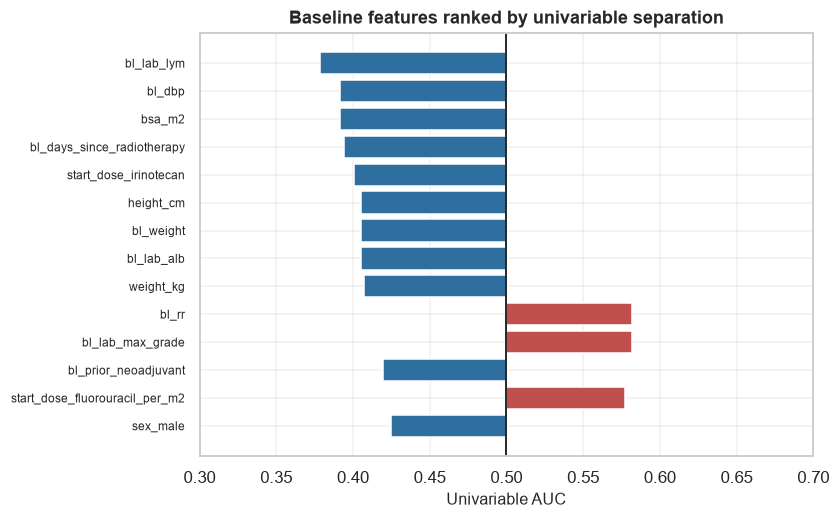

Strongest univariable separation: bl_lab_lym (AUC 0.378, i.e. 0.122 from chance; lower values indicate risk)
Features with p < 0.05: 16 of 91 (5 expected by chance alone)


In [ ]:
top = screen.head(14).iloc[::-1]
fig, ax = plt.subplots(figsize=(7.2, 5.0))
colours = [plots.PALETTE[1] if v > 0.5 else plots.PALETTE[0]
           for v in top["univariable_auc"]]
ax.barh(top["feature"], top["univariable_auc"] - 0.5, left=0.5, color=colours)
ax.axvline(0.5, c="k", lw=1.2)
ax.set(xlabel="Univariable AUC", title="Baseline features ranked by univariable separation",
       xlim=(0.3, 0.7))
ax.tick_params(axis="y", labelsize=8)
plots.save(fig, "03_univariable_screen")
plt.show()

top1 = screen.iloc[0]
print(f"Strongest univariable separation: {top1['feature']} "
      f"(AUC {top1['univariable_auc']:.3f}, i.e. {top1['abs_auc_gap']:.3f} from chance; "
      f"{'higher' if top1['univariable_auc'] > 0.5 else 'lower'} values indicate risk)")
print(f"Features with p < 0.05: {(screen['p_value'] < 0.05).sum()} of {len(screen)} "
      f"({0.05 * len(screen):.0f} expected by chance alone)")


The screen indicates that **no baseline variable separates the classes strongly**: the best
is only ~0.12 away from chance. Sixteen features reach nominal p < 0.05 against ~5 expected
by chance, so there is *some* real baseline association — but it is weak and spread thinly
across many variables rather than concentrated in a few strong predictors.

This is a substantive finding rather than a technical shortcoming: the dominant severe
toxicity in this regimen is neutropenia, which depends on marrow reserve and on the
laboratory values now available but measured only at screening. Baseline discrimination
should therefore be
expected to be weak.

## 3. Train / test split

The test set is held out at the **patient** level and is never touched until §6.

In [ ]:
train_idx, test_idx = modeling.grouped_train_test_split(X, y, groups)
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
g_train = pd.Series(X_train.index, index=X_train.index)

print(f"Train: {len(X_train)} patients, {int(y_train.sum())} events ({y_train.mean():.1%})")
print(f"Test : {len(X_test)} patients, {int(y_test.sum())} events ({y_test.mean():.1%})")

Train: 252 patients, 58 events (23.0%)
Test : 126 patients, 29 events (23.0%)



## 4. Cross-validated model comparison

Six candidate learners are compared with 5-fold stratified cross-validation on the
training patients. Class imbalance is handled by class weighting rather than resampling,
so probabilities remain interpretable after the recalibration step in §6.

In [ ]:
zoo = modeling.build_model_zoo(X_train)
print(f"Candidate models: {list(zoo)}\n")
cv_results = modeling.cross_validate_models(zoo, X_train.reset_index(drop=True),
                                            y_train.reset_index(drop=True),
                                            g_train.reset_index(drop=True))

Candidate models: ['Logistic Regression', 'Elastic-Net Logistic', 'Random Forest', 'Hist Gradient Boosting', 'XGBoost', 'LightGBM']



  Logistic Regression        AUROC=0.569  AUPRC=0.268  Brier=0.3162


  Elastic-Net Logistic       AUROC=0.575  AUPRC=0.267  Brier=0.2814


  Random Forest              AUROC=0.616  AUPRC=0.319  Brier=0.1824


  Hist Gradient Boosting     AUROC=0.513  AUPRC=0.243  Brier=0.1805


  XGBoost                    AUROC=0.528  AUPRC=0.264  Brier=0.2039


  LightGBM                   AUROC=0.560  AUPRC=0.304  Brier=0.2089


In [ ]:
oof = {name: r.oof_pred for name, r in cv_results.items()}
cv_table = evaluation.metrics_table(oof, y_train.to_numpy())
cv_table.to_csv(TABLE_DIR / "03_static_cv_metrics.csv", index=False)
cv_table

,model,n,n_events,event_rate,auroc,auprc,auprc_lift,brier,scaled_brier,log_loss,calib_intercept,calib_slope
0,Random Forest,252,58,0.2302,0.6160,0.3192,1.3867,0.1824,-0.0292,0.5491,-0.5708,0.9067
1,Elastic-Net Logistic,252,58,0.2302,0.5750,0.2667,1.1588,0.2814,-0.5882,1.0641,-1.1606,0.0448
2,Logistic Regression,252,58,0.2302,0.5692,0.2685,1.1665,0.3162,-0.7844,1.5755,-1.1519,0.0316
3,LightGBM,252,58,0.2302,0.5603,0.3039,1.3202,0.2089,-0.1791,0.7182,-0.9952,0.1095
4,XGBoost,252,58,0.2302,0.5276,0.2636,1.1452,0.2039,-0.1506,0.6803,-1.1246,0.0444
5,Hist Gradient Boosting,252,58,0.2302,0.5130,0.2434,1.0575,0.1805,-0.0185,0.5481,-1.1750,0.0260


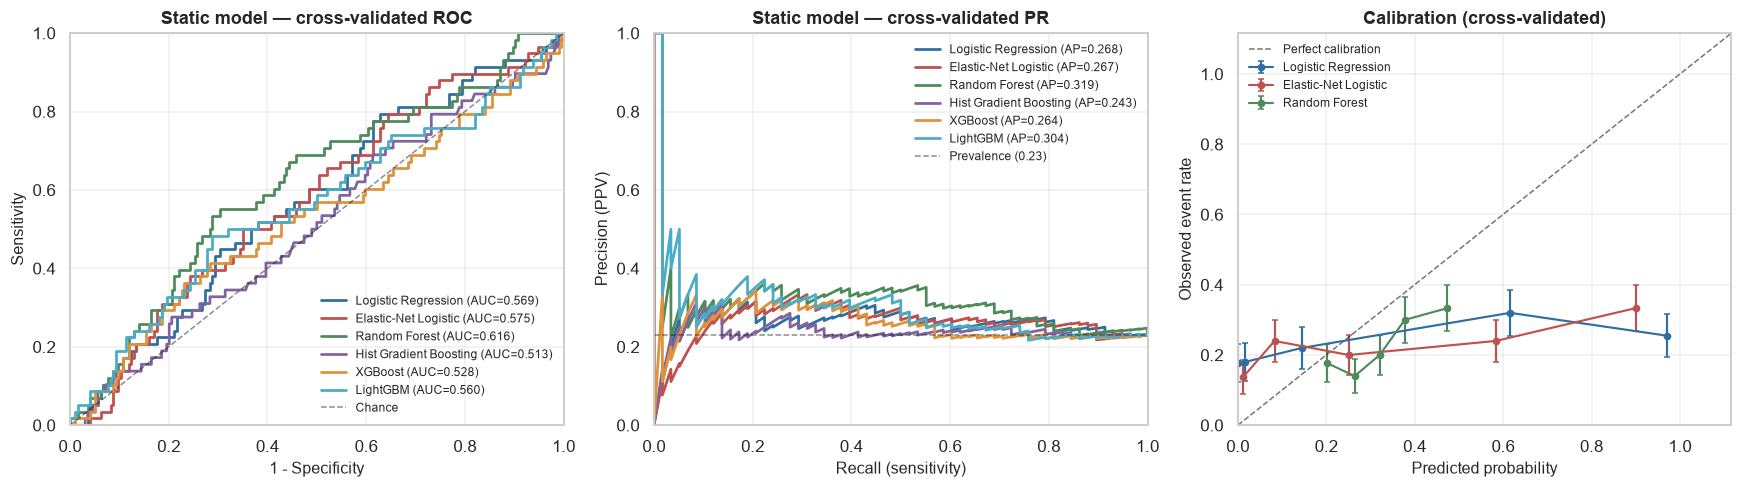

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16.0, 4.6))
plots.plot_roc_curves(y_train.to_numpy(), oof,
                      title="Static model — cross-validated ROC", ax=axes[0])
plots.plot_pr_curves(y_train.to_numpy(), oof,
                     title="Static model — cross-validated PR", ax=axes[1])
calib = {n: evaluation.calibration_table(y_train.to_numpy(), p, n_bins=5)
         for n, p in list(oof.items())[:3]}
plots.plot_calibration(calib, title="Calibration (cross-validated)", ax=axes[2])
fig.tight_layout()
plots.save(fig, "03_static_cv_performance")
plt.show()

Best cross-validated model: Random Forest (AUROC = 0.616)


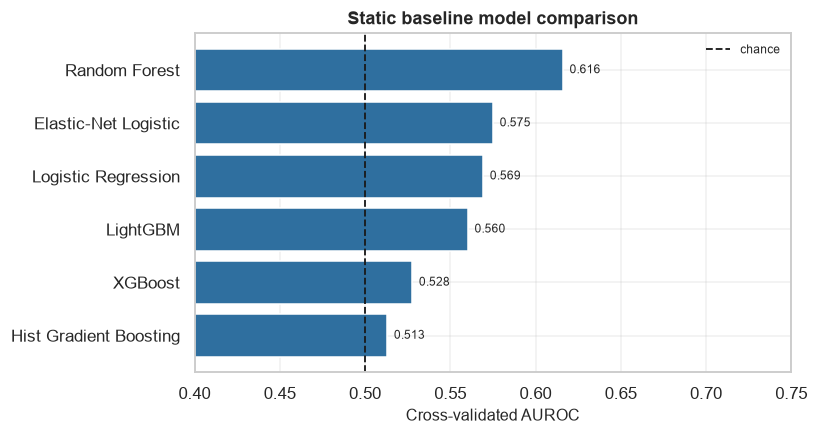

In [ ]:
best_name = cv_table.iloc[0]["model"]
print(f"Best cross-validated model: {best_name} (AUROC = {cv_table.iloc[0]['auroc']:.3f})")

fig, ax = plt.subplots(figsize=(7.0, 4.0))
order = cv_table.sort_values("auroc")
ax.barh(order["model"], order["auroc"], color=plots.PALETTE[0])
ax.axvline(0.5, ls="--", c="k", lw=1.2, label="chance")
ax.set(xlabel="Cross-validated AUROC", xlim=(0.4, 0.75),
       title="Static baseline model comparison")
ax.legend(fontsize=8)
for i, (m, v) in enumerate(zip(order["model"], order["auroc"])):
    ax.text(v + 0.004, i, f"{v:.3f}", va="center", fontsize=8)
plots.save(fig, "03_static_model_comparison")
plt.show()


## 5. Interpreting the reference model

The logistic regression is reported in full regardless of whether it wins on AUROC,
because the dissertation's design principle is that an interpretable benchmark must be
available for clinical scrutiny.

In [ ]:
lr = zoo["Logistic Regression"]
lr_fitted, _ = modeling.fit_and_predict(lr, X_train, y_train, X_test)

names = modeling.feature_names_out(lr_fitted)
coefs = lr_fitted.named_steps["clf"].coef_[0]
coef_tbl = (pd.DataFrame({"feature": names, "coefficient": coefs})
              .assign(odds_ratio=lambda d: np.exp(d["coefficient"]),
                      abs_coef=lambda d: d["coefficient"].abs())
              .sort_values("abs_coef", ascending=False))
coef_tbl.to_csv(TABLE_DIR / "03_static_logistic_coefficients.csv", index=False)
coef_tbl.head(20).reset_index(drop=True)

,feature,coefficient,odds_ratio,abs_coef
0,missingindicator_bl_lab_eos,1.0885,2.9698,1.0885
1,bl_lab_mono,1.0788,2.9411,1.0788
2,missingindicator_bl_lab_tprot,-0.9178,0.3994,0.9178
3,missingindicator_bl_days_since_prior_therapy,-0.9101,0.4025,0.9101
4,bl_sld_mm,0.8867,2.4271,0.8867
5,race_Black,-0.8688,0.4195,0.8688
6,missingindicator_bl_days_since_radiotherapy,-0.8571,0.4244,0.8571
7,bl_lab_wbc,-0.8169,0.4418,0.8169
8,n_ongoing_conditions,-0.7943,0.4519,0.7943
9,bl_lab_bun,-0.7852,0.4560,0.7852


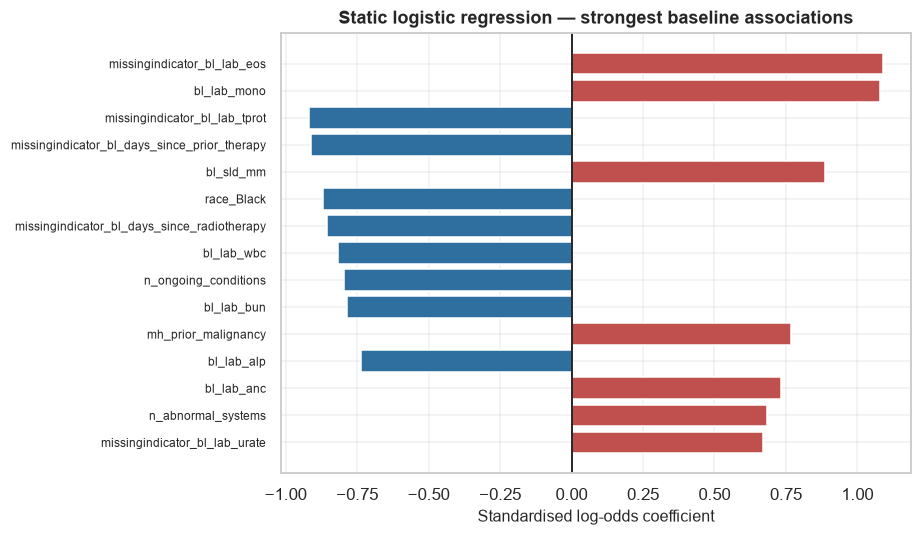

In [ ]:
top = coef_tbl.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(7.4, 5.2))
colours = [plots.PALETTE[1] if c > 0 else plots.PALETTE[0] for c in top["coefficient"]]
ax.barh(top["feature"], top["coefficient"], color=colours)
ax.axvline(0, c="k", lw=1.2)
ax.set(xlabel="Standardised log-odds coefficient",
       title="Static logistic regression — strongest baseline associations")
ax.tick_params(axis="y", labelsize=8)
plots.save(fig, "03_static_logistic_coefficients")
plt.show()


## 6. Held-out test evaluation

The best cross-validated model is refitted on all training patients, **recalibrated on a
disjoint subset of training patients**, and evaluated once on the untouched test patients.
Confidence intervals come from a patient-level bootstrap.

In [ ]:
best_model = zoo[best_name]
fitted, p_raw = modeling.fit_and_predict(best_model, X_train, y_train, X_test)
calibrated, p_cal = modeling.fit_with_calibration(best_model, X_train, y_train,
                                                  g_train, X_test, method="sigmoid")

test_preds = {f"{best_name} (raw)": p_raw, f"{best_name} (calibrated)": p_cal}
test_table = evaluation.metrics_table(test_preds, y_test.to_numpy())
test_table.to_csv(TABLE_DIR / "03_static_test_metrics.csv", index=False)
test_table

,model,n,n_events,event_rate,auroc,auprc,auprc_lift,brier,scaled_brier,log_loss,calib_intercept,calib_slope
0,Random Forest (raw),126,29,0.2302,0.6168,0.2942,1.2783,0.1862,-0.0508,0.5578,-0.6968,0.7770
1,Random Forest (calibrated),126,29,0.2302,0.6086,0.2871,1.2476,0.1739,0.0184,0.5294,-0.0587,1.0373


In [ ]:
for label, p in test_preds.items():
    auroc, lo, hi = evaluation.bootstrap_metric_ci(y_test.to_numpy(), p, metric="auroc")
    auprc, plo, phi = evaluation.bootstrap_metric_ci(y_test.to_numpy(), p, metric="auprc")
    print(f"{label:34s} AUROC {auroc:.3f} [{lo:.3f}, {hi:.3f}]   "
          f"AUPRC {auprc:.3f} [{plo:.3f}, {phi:.3f}]")

Random Forest (raw)                AUROC 0.617 [0.500, 0.711]   AUPRC 0.294 [0.191, 0.437]


Random Forest (calibrated)         AUROC 0.609 [0.501, 0.715]   AUPRC 0.287 [0.185, 0.430]


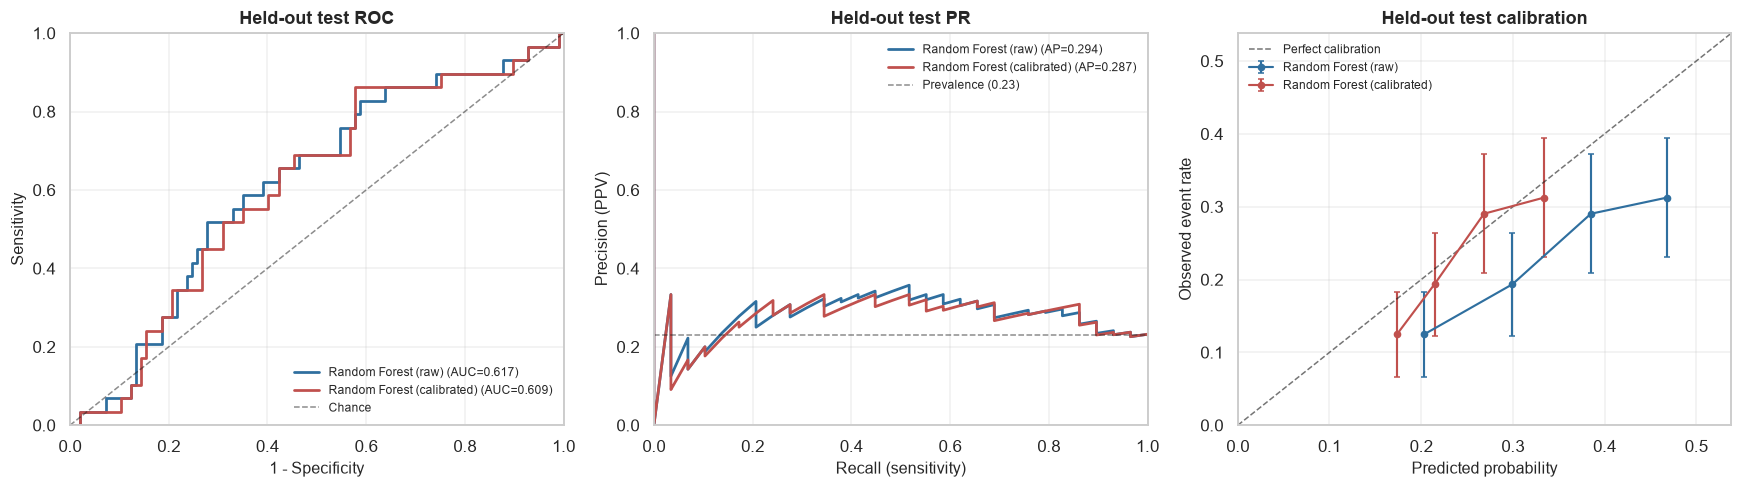

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16.0, 4.6))
plots.plot_roc_curves(y_test.to_numpy(), test_preds, title="Held-out test ROC", ax=axes[0])
plots.plot_pr_curves(y_test.to_numpy(), test_preds, title="Held-out test PR", ax=axes[1])
plots.plot_calibration(
    {k: evaluation.calibration_table(y_test.to_numpy(), v, n_bins=4)
     for k, v in test_preds.items()},
    title="Held-out test calibration", ax=axes[2])
fig.tight_layout()
plots.save(fig, "03_static_test_performance")
plt.show()


### Operating points

A safety-monitoring alert is only useful at a specific threshold. The table below shows
the trade-off; in a monitoring context sensitivity is usually prioritised, accepting a
higher alert rate.

In [ ]:
thr_tbl = evaluation.threshold_table(y_test.to_numpy(), p_cal)
thr_tbl.to_csv(TABLE_DIR / "03_static_threshold_table.csv", index=False)
display(thr_tbl[["threshold", "sensitivity", "specificity", "ppv", "npv",
                 "f1", "balanced_accuracy", "alert_rate"]])

best_f1 = thr_tbl.loc[thr_tbl["f1"].idxmax()]
print(f"\nBest-F1 threshold {best_f1['threshold']:.2f}: "
      f"sensitivity {best_f1['sensitivity']:.2f}, specificity {best_f1['specificity']:.2f}, "
      f"PPV {best_f1['ppv']:.2f}, alert rate {best_f1['alert_rate']:.0%}")

,threshold,sensitivity,specificity,ppv,npv,f1,balanced_accuracy,alert_rate
0,0.0500,1.0000,0.0000,0.2302,NaN,0.3742,0.5000,1.0000
1,0.1000,1.0000,0.0000,0.2302,NaN,0.3742,0.5000,1.0000
2,0.1500,0.9655,0.0103,0.2258,0.5000,0.3660,0.4879,0.9841
3,0.2000,0.8621,0.3196,0.2747,0.8857,0.4167,0.5908,0.7222
4,0.2500,0.6207,0.5773,0.3051,0.8358,0.4091,0.5990,0.4683
5,0.3000,0.3448,0.7938,0.3333,0.8021,0.3390,0.5693,0.2381
6,0.3500,0.0345,0.9485,0.1667,0.7667,0.0571,0.4915,0.0476
7,0.4000,0.0000,0.9897,0.0000,0.7680,NaN,0.4948,0.0079
8,0.4500,0.0000,1.0000,NaN,0.7698,NaN,0.5000,0.0000
9,0.5000,0.0000,1.0000,NaN,0.7698,NaN,0.5000,0.0000



Best-F1 threshold 0.20: sensitivity 0.86, specificity 0.32, PPV 0.27, alert rate 72%


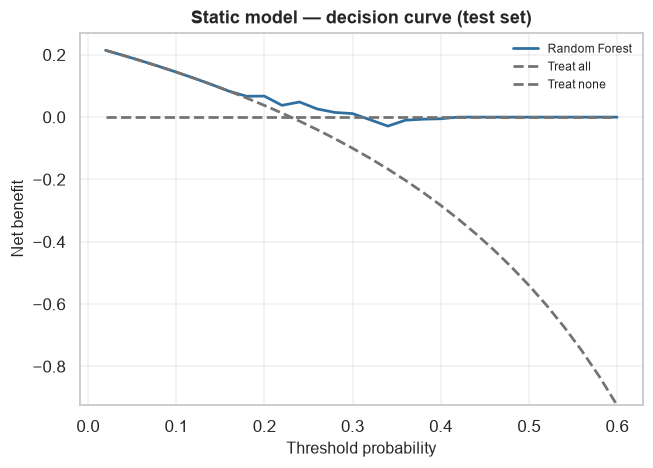

In [ ]:
dc = evaluation.decision_curve(y_test.to_numpy(), {best_name: p_cal})
fig, ax = plt.subplots(figsize=(6.6, 4.4))
plots.plot_decision_curve(dc, title="Static model — decision curve (test set)", ax=ax)
plots.save(fig, "03_static_decision_curve")
plt.show()


## 6.5  Pre-enrolment screening

A reviewer of the mid-semester report asked for a **pre-check at the start of treatment**:
a step that recommends whether a patient should be enrolled at all. This section builds
that system and validates it.

It begins with whether the **model on its own** can be that rule, because the answer
determines how the system has to be designed.

### 6.5.1  Why the model alone cannot be the rule

Note first that the consequence of a positive call is not an extra blood test but **denial
of second-line therapy to a patient with metastatic colorectal cancer**, so the two error
types are in no sense symmetric and cannot be traded off with a single F1 score.

The table below counts, at each exclusion threshold, how many patients would be refused,
how many severe events that would actually avert, and — the column that decides it — how
many patients would be **denied treatment for nothing**.


In [ ]:
enrol = evaluation.enrolment_screening_table(y_test.to_numpy(), p_cal)
enrol.to_csv(TABLE_DIR / "03_enrolment_screening.csv", index=False)
display(enrol[enrol["n_excluded"] > 0][
    ["threshold", "n_excluded", "pct_cohort_excluded", "events_averted",
     "events_missed", "wrongly_excluded", "nne", "harm_ratio"]])

usable = enrol[(enrol["events_averted"] > 0) & (enrol["n_excluded"] < len(y_test))]
best = usable.loc[usable["nne"].idxmin()]
print(f"\nMost favourable operating point (threshold {best['threshold']:.2f}):")
print(f"  exclude {best['n_excluded']:.0f} of {len(y_test)} patients "
      f"({best['pct_cohort_excluded']:.0%} of the cohort)")
print(f"  severe events averted        : {best['events_averted']:.0f} of "
      f"{int(y_test.sum())}")
print(f"  severe events still missed   : {best['events_missed']:.0f}")
print(f"  patients denied treatment who would NOT have had a severe event: "
      f"{best['wrongly_excluded']:.0f}")
print(f"  number needed to exclude to avert one event : {best['nne']:.1f}")
print(f"  wrongly excluded per event averted          : {best['harm_ratio']:.1f}")


,threshold,n_excluded,pct_cohort_excluded,events_averted,events_missed,wrongly_excluded,nne,harm_ratio
0,0.1000,126,1.0000,29,0,97,4.3448,3.3448
1,0.1500,124,0.9841,28,1,96,4.4286,3.4286
2,0.2000,91,0.7222,25,4,66,3.6400,2.6400
3,0.2500,59,0.4683,18,11,41,3.2778,2.2778
4,0.3000,30,0.2381,10,19,20,3.0000,2.0000
5,0.3500,6,0.0476,1,28,5,6.0000,5.0000
6,0.4000,1,0.0079,0,29,1,NaN,NaN



Most favourable operating point (threshold 0.30):
  exclude 30 of 126 patients (24% of the cohort)
  severe events averted        : 10 of 29
  severe events still missed   : 19
  patients denied treatment who would NOT have had a severe event: 20
  number needed to exclude to avert one event : 3.0
  wrongly excluded per event averted          : 2.0


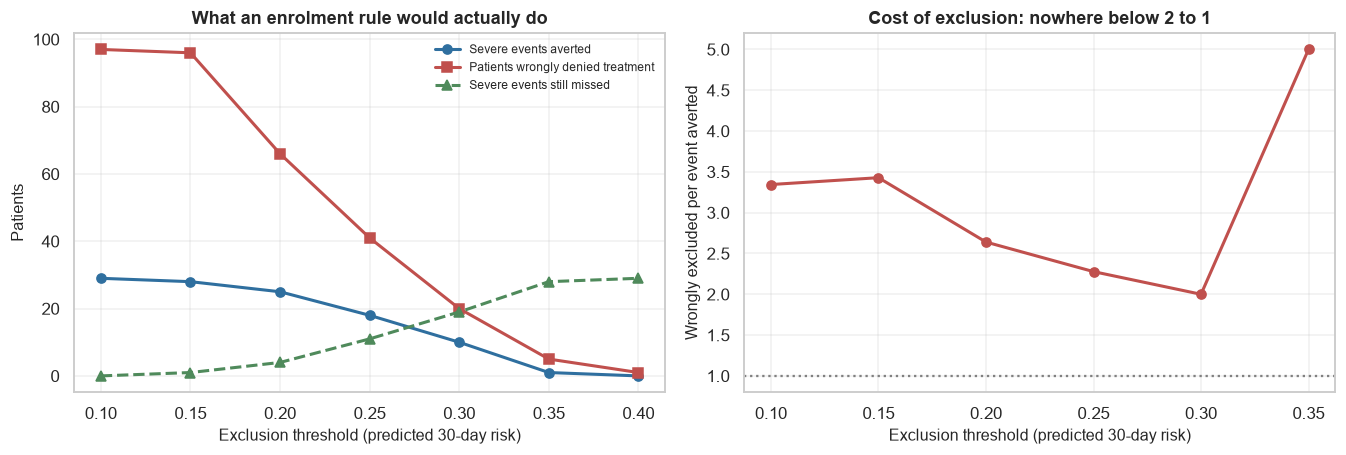

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.3))
e = enrol[enrol["n_excluded"] > 0]

axes[0].plot(e["threshold"], e["events_averted"], marker="o", lw=2,
             color=plots.PALETTE[0], label="Severe events averted")
axes[0].plot(e["threshold"], e["wrongly_excluded"], marker="s", lw=2,
             color=plots.PALETTE[1], label="Patients wrongly denied treatment")
axes[0].plot(e["threshold"], e["events_missed"], marker="^", lw=2, ls="--",
             color=plots.PALETTE[2], label="Severe events still missed")
axes[0].set(xlabel="Exclusion threshold (predicted 30-day risk)", ylabel="Patients",
            title="What an enrolment rule would actually do")
axes[0].legend(fontsize=8)

axes[1].plot(e["threshold"], e["harm_ratio"], marker="o", lw=2, color=plots.PALETTE[1])
axes[1].axhline(1.0, ls=":", c="grey")
axes[1].set(xlabel="Exclusion threshold (predicted 30-day risk)",
            ylabel="Wrongly excluded per event averted",
            title="Cost of exclusion: nowhere below 2 to 1")
fig.tight_layout()
plots.save(fig, "03_enrolment_screening")
plt.show()



**So a threshold on the model cannot be the rule.** At its most favourable operating point
it must refuse roughly **three patients to avert one severe adverse event**, about **two of
those three would never have had one**, and it still misses a third of the events. Push the
threshold higher and it stops excluding anybody; lower it and it excludes the entire cohort.
That is the arithmetic consequence of a held-out AUROC of 0.609 whose interval reaches down to 0.501 and includes
chance — a screening rule inherits the discrimination of the score behind it.

Two further points shape the design that follows:

1. **The outcome is not a contraindication.** A CTCAE Grade ≥3 event is serious but usually
   *manageable* on this regimen — dose reduction, growth-factor support, supportive care.
   Preventing it by withholding chemotherapy trades a manageable toxicity for an untreated
   cancer.
2. **Real trial screening does not work by prediction.** It works by *measurement*: organ
   function adequate to metabolise and tolerate the drug. Those are facts about the patient
   on the day, not forecasts, and they are what can legitimately stop treatment starting.

So the implemented system below puts the measurements in charge of the enrolment decision,
and demotes the model to what the evidence actually supports — setting monitoring intensity.



### 6.5.2  The implemented pre-enrolment check

`aeprep.enrolment` runs three layers before the first dose, using only screening data.

**Layer 1 — protocol safety criteria.** Objective organ-function and performance thresholds
of the kind written into oncology eligibility sections: marrow reserve, the irinotecan
bilirubin constraint, transaminases, renal clearance, albumin and ECOG. Each is tagged
`exclusion` or `caution`, and separately as reversible or not — which is what distinguishes
*defer and recheck* from *do not enrol*. These thresholds come from standard second-line
colorectal practice and were fixed **before any outcome was inspected**.

**Layer 2 — model baseline risk.** The static model's calibrated probability of a Grade ≥3
event in days 1–31. It can raise monitoring intensity; by design it can never exclude anyone.

**Layer 3 — recommendation.** One of four postures, returned with every criterion that fired,
its measured value and its threshold.

A fourth severity, `data`, marks a panel that could not be completed. It is reported but
deliberately kept out of the decision — §6.5.3 shows why that separation matters.


In [ ]:
from aeprep import enrolment

panel = enrolment.baseline_screening_panel(domains, timeline)
print(f"Screening panel: {panel.shape[0]} patients x {panel.shape[1] - 1} measurements")

baseline_risk = pd.read_parquet(DATASET_DIR / "static_test_predictions.parquet") \
                  .set_index("PID")["p_static_calibrated"]

screened = enrolment.screen_cohort(panel, baseline_risk)
screened.to_csv(TABLE_DIR / "03_enrolment_screening_decisions.csv", index=False)

dist = (screened["recommendation"].value_counts().sort_index()
        .rename("n_patients").to_frame())
dist["pct"] = (100 * dist["n_patients"] / len(screened)).round(1)
display(dist)

from collections import Counter
counts = Counter()
for col in ("exclusion_keys", "caution_keys", "data_flag_keys"):
    for s in screened[col]:
        for k in [x for x in s.split("; ") if x]:
            counts[k] += 1
crit_tbl = pd.DataFrame(
    [{"criterion": c.key, "severity": c.severity, "reversible": c.reversible,
      "n_patients_flagged": counts.get(c.key, 0)} for c in enrolment.SCREENING_CRITERIA])
crit_tbl.to_csv(TABLE_DIR / "03_enrolment_criteria_frequency.csv", index=False)
display(crit_tbl)


Screening panel: 379 patients x 17 measurements


,n_patients,pct
recommendation,,
DO NOT ENROL,0,0.0000
DEFER AND RECHECK,25,6.6000
ENROL WITH INTENSIFIED MONITORING,145,38.3000
ENROL - STANDARD MONITORING,209,55.1000


,criterion,severity,reversible,n_patients_flagged
0,anc_inadequate,exclusion,True,1
1,anc_borderline,caution,True,7
2,plt_inadequate,exclusion,True,0
3,plt_borderline,caution,True,12
4,hgb_inadequate,exclusion,True,5
5,hgb_borderline,caution,True,39
6,bili_high,exclusion,True,5
7,bili_borderline,caution,True,17
8,transaminase_high,exclusion,True,16
9,creat_high,exclusion,True,0



**No patient receives `DO NOT ENROL`, and that is the correct result.** The only
non-reversible exclusion is ECOG ≥ 2, and every patient here is ECOG 0 or 1 — 202 and 177
respectively. That is not a quirk: these 379 patients *already passed* the trial's own
screening, so a pre-check that rejected any of them outright would be contradicting a
decision a clinician already made correctly. The system instead **defers 25 patients** whose
organ-function values fall outside protocol limits, which is exactly the recoverable
situation such a check exists to catch.

The corollary matters for everything below: this cohort **cannot** contain true screen
failures, because Project Data Sphere releases only enrolled patients. The validation
therefore asks a weaker but still meaningful question — among patients who *were* accepted,
does the check identify those who went on to tolerate treatment badly?


In [ ]:
# Validation: does the check separate patients who then tolerated treatment badly?
static_target = labels.static_label(ae, timeline).set_index("PID")
outcomes = timeline[["PID", "treatment_duration", "discont_due_to_ae", "died"]].copy()
outcomes["y_early"] = outcomes["PID"].map(static_target["y"])
outcomes["discont_due_to_ae"] = outcomes["discont_due_to_ae"].astype(float)
outcomes["died"] = outcomes["died"].astype(float)

val = enrolment.validate_screening(screened, outcomes)
val.to_csv(TABLE_DIR / "03_enrolment_validation.csv", index=False)
display(val.round(3))

crit_audit = enrolment.criterion_outcome_table(screened, outcomes)
crit_audit.to_csv(TABLE_DIR / "03_enrolment_criterion_audit.csv", index=False)
print(f"Base early-severe-AE rate: {crit_audit.attrs['base_rate']:.3f}\n")
display(crit_audit.round(3))


,recommendation,n_patients,early_severe_ae_rate,median_treatment_days,discont_due_to_ae_rate,death_rate
0,DO NOT ENROL,0,NaN,NaN,NaN,NaN
1,DEFER AND RECHECK,25,0.3600,188.0000,0.4400,0.6400
2,ENROL WITH INTENSIFIED MONITORING,145,0.3170,198.0000,0.1310,0.3790
3,ENROL - STANDARD MONITORING,209,0.1530,241.0000,0.0770,0.3680


Base early-severe-AE rate: 0.230



,criterion,severity,n_flagged,outcome_rate,lift_vs_base,median_treatment_days
0,incomplete_panel,data,72,0.1940,0.8470,215.0000
1,albumin_borderline,caution,49,0.3670,1.6000,140.0000
2,prior_pelvic_rt,caution,47,0.2770,1.2050,209.0000
3,hgb_borderline,caution,39,0.3850,1.6760,155.0000
4,bili_borderline,caution,17,0.4120,1.7940,215.0000
5,transaminase_high,exclusion,16,0.3120,1.3610,210.0000
6,elderly,caution,15,0.2000,0.8710,272.0000
7,plt_borderline,caution,12,0.2500,1.0890,244.5000
8,prior_toxicity_stop,caution,9,0.4440,1.9360,222.0000
9,anc_borderline,caution,7,0.7140,3.1120,266.0000


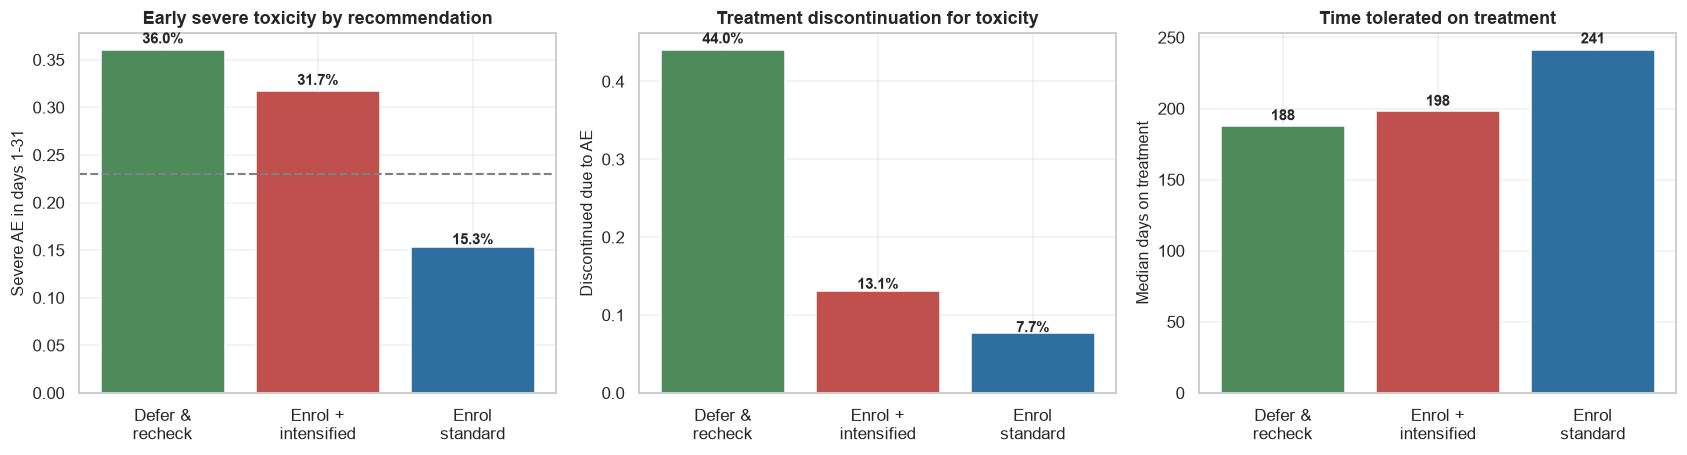

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.3))
order = ["DEFER AND RECHECK", "ENROL WITH INTENSIFIED MONITORING", "ENROL - STANDARD MONITORING"]
short = ["Defer &\nrecheck", "Enrol +\nintensified", "Enrol\nstandard"]
v = val.set_index("recommendation").reindex(order)
cols = [plots.PALETTE[2], plots.PALETTE[1], plots.PALETTE[0]]

for ax, col, lab, title, fmt in [
        (axes[0], "early_severe_ae_rate", "Severe AE in days 1-31",
         "Early severe toxicity by recommendation", "pct"),
        (axes[1], "discont_due_to_ae_rate", "Discontinued due to AE",
         "Treatment discontinuation for toxicity", "pct"),
        (axes[2], "median_treatment_days", "Median days on treatment",
         "Time tolerated on treatment", "num")]:
    ax.bar(short, v[col], color=cols)
    ax.set(ylabel=lab, title=title)
    for i, value in enumerate(v[col]):
        txt = f"{value:.1%}" if fmt == "pct" else f"{value:.0f}"
        ax.text(i, value * 1.02, txt, ha="center", fontsize=10, weight="bold")
axes[0].axhline(outcomes["y_early"].mean(), ls="--", c="grey", lw=1.4)

fig.tight_layout()
plots.save(fig, "03_enrolment_validation")
plt.show()


In [ ]:
# The screening note a trial team would file, for the most heavily flagged patient.
worst = screened.sort_values(["n_exclusions", "n_cautions"], ascending=False).iloc[0]["PID"]
row = panel[panel["PID"].eq(worst)].iloc[0]
print(enrolment.format_screening_report(
    enrolment.screen_patient(row, baseline_risk.get(worst))))


 PRE-ENROLMENT SCREENING  -  PATIENT 0308
 RECOMMENDATION: DEFER AND RECHECK
   A reversible criterion is not met. Repeat the failing test and reassess rather than refusing the patient outright.

 PROTOCOL CRITERIA NOT MET (2)
   1. Total bilirubin above 1.5 x upper limit of normal
      Measured: Bilirubin 2.42 x ULN (limit 1.5)
      Reversible - repeat the test
      Why: Irinotecan is cleared hepatically and its active metabolite SN-38 is glucuronidated; raised bilirubin sharply increases exposure and the risk of severe neutropenia and diarrhoea. This is the single firmest pharmacological contraindication in the regimen.
   2. ALT or AST above 2.5 x upper limit of normal
      Measured: ALT 1.64 x ULN, AST 3.27 x ULN (limit 2.5)
      Reversible - repeat the test
      Why: Hepatocellular injury at this level compromises clearance of both cytotoxic components.

 CAUTIONS (1) - do not prevent enrolment
   1. Serum albumin 2.5 to 3.5 g/dL  [Albumin 2.70 g/dL (below reference range)]



**The check separates outcomes in the intended direction, and by a wide margin.** Early
severe toxicity runs at 36.0% in the deferred group and 31.7% in the intensified group
against 15.3% in those cleared for standard monitoring; discontinuation *for toxicity* is
44.0% and 13.1% against 7.7%; and patients cleared for standard monitoring stay on
treatment roughly 43 days longer at the median.

The per-criterion audit is what keeps this honest, and it earns its place twice over.
Every clinical criterion flags patients at or above the 23.0% base rate — the borderline
neutrophil count at 3.1× and a bilirubin above 1.5 × ULN at 2.6× being the strongest — so
no single criterion is carrying the aggregate result alone. But two entries fire *below*
base rate and are findings rather than noise:

* **`incomplete_panel` (0.85×)** flags 72 patients and does not track risk at all, which is
  correct: an incomplete panel means the check could not be finished, not that the patient
  is unwell. This is why it carries the `data` severity and is excluded from the decision.
  Before that separation it pulled 45 low-risk patients into intensified monitoring.
* **`elderly` (0.87×)** shows that age alone does not predict early toxicity here. It is
  kept as a dose-discussion prompt, not a risk marker, and the number is reported rather
  than quietly dropped.

Two limits travel with this system. It cannot be validated against true screen failures,
because none exist in a dataset of enrolled patients. And the criteria encode accepted
practice rather than learned thresholds — which is the point, since that is what makes them
defensible as an enrolment rule when a 0.609 AUROC is not.



## 7. Persist the model

In [ ]:
import joblib

joblib.dump({"model": calibrated, "raw_model": fitted, "feature_columns": list(X.columns),
             "best_name": best_name, "config": CFG.as_dict()},
            MODEL_DIR / "static_baseline_model.joblib")

static_predictions = pd.DataFrame({
    "PID": X_test.index, "y": y_test.to_numpy(),
    "p_static_raw": p_raw, "p_static_calibrated": p_cal})
static_predictions.to_parquet(DATASET_DIR / "static_test_predictions.parquet", index=False)

# The full-cohort static model is refitted here so notebook 05 can apply the *frozen*
# static score at every landmark for the head-to-head comparison.
full_model, _ = modeling.fit_and_predict(best_model, X_train, y_train, X_test)
joblib.dump({"model": full_model, "feature_columns": list(X.columns),
             "train_pids": list(X_train.index), "test_pids": list(X_test.index)},
            MODEL_DIR / "static_model_for_comparison.joblib")
print("saved static model artefacts")

saved static model artefacts



---

## Summary of this notebook

| Result | Value |
|---|---|
| Analytic dataset | 378 patients × 92 baseline features (28 laboratory, 15 disease burden and treatment history) |
| Positive class (severe AE in days 1–31) | 87 patients (23.0%) |
| Best cross-validated AUROC | **0.616** (Random Forest); range across six learners 0.51–0.62 |
| Held-out test AUROC | **0.609** calibrated [0.501, 0.715] / 0.617 raw [0.500, 0.711] |
| Strongest univariable baseline predictor | baseline lymphocyte count, 0.122 away from chance |

**Interpretation — stated plainly.** The static baseline model has **little generalisable
discriminative signal**. The held-out interval's lower bound clears 0.5 by only 0.001, and the
best-F1 operating point degenerates to alerting on every patient. This is a negative
result and it is reported as one.

Two reasons, both documented rather than assumed:

1. the dominant severe toxicity is **neutropenia**, and although the `LAB_SAFE` panel is
   present, only its *screening* values are available to a model frozen at first dose;
2. more fundamentally, baseline covariates are a **weak proxy for a risk that evolves** —
   established empirically in notebook 02, where the majority of first severe events
   occurred after day 30, entirely outside this model's window.

Far from undermining the dissertation, this is the result that motivates it. The claim
being tested is not that severe adverse events are easy to predict from enrolment data —
they demonstrably are not — but that **updating the prediction with in-trial information
materially improves it**. Notebook 05 tests exactly that, against this benchmark, on
identical patients.